In [ ]:

import os
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import random_split
from torch.utils.data import DataLoader,Dataset

import cv2 as cv
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt


In [ ]:


# reproducicbility:
random.seed(42)
torch.manual_seed(42)


In [ ]:


# check for cuda compatibility:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = torch.device(device)
device


device(type='cuda')

In [ ]:

# read all the images:
base_path = r"/content"
img_dir = os.path.join(base_path, "img_align_celeba")
img_dir

'/content/img_align_celeba'

<br>
<br>

# `#01: Dataset, batching and transformation`

<br>
<br>

In [ ]:


class CustomDataset(Dataset):
    def __init__(self,img_dir,transform):
        super().__init__()
        self.img_dir = img_dir
        self.img_files = os.listdir(img_dir)
        self.transform = transform


    def __len__(self)->int:
        return len(self.img_files)

    def __getitem__(self, index):
        path = self.img_files[index]
        final_path = os.path.join(self.img_dir,path)
        #print(final_path)
        img = Image.open(final_path).convert("RGB")
        image = self.transform(img)
        return image


torch.float32
shape:  torch.Size([3, 128, 128])


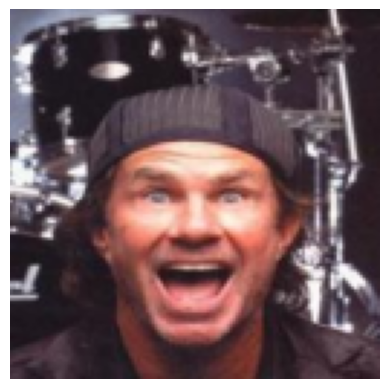

In [ ]:
# trainsformation: it's automatically Nomalize the image:
transfrom = transforms.Compose([
    transforms.Resize(size=(128,128)),
    transforms.ToTensor() # [255,255,3] -> [0~1,0~1,0~1,3]
    ])


# create instance of the image dataset:
dataset = CustomDataset(img_dir,transfrom)
img = dataset.__getitem__(100)

# we know pytorch like: [depth,heigh,width]
print(img.dtype)
print("shape: ",img.shape)
plt.axis("off")
plt.imshow(img.permute(1,2,0))
plt.show()


In [ ]:

dataset.__len__()


202599

In [ ]:

# prepare dataset for tranning and testing:
dataset_length = dataset.__len__()
print("\n\n dataset length: {}".format(dataset_length))

train_size = int(0.8 * dataset_length)
print("train_dataset_length: {}".format(train_size))

test_size = dataset_length - train_size
print("test_dataset_length: {}".format(test_size))




 dataset length: 202599
train_dataset_length: 162079
test_dataset_length: 40520


In [ ]:

# train test spliting:
train,test = random_split(dataset=dataset,lengths=[train_size,test_size])
print(f"spilting_train_size: {len(train)}")
print(f"spilting_test_size: {len(test)}")

spilting_train_size: 162079
spilting_test_size: 40520


In [ ]:

# batching:64 the data with DataLoader
train_loader  = DataLoader(dataset=train,batch_size=64,shuffle=True,drop_last=True)
test_loader = DataLoader(dataset=test,batch_size=64,shuffle=False,drop_last=True)


In [ ]:

# check that batching is done correctly or not:
# [Batch_dim, channe_dim, img_height, img_width]
iterator = iter(train_loader)
next(iterator).shape

torch.Size([64, 3, 128, 128])

<br>
<br>

# `#02: Making the model`

<br>
<br>

In [ ]:

# build the VariationalAutoEncoder Model:

class VariationalAutoEncoder(nn.Module):
    def __init__(self,in_channels,latent_dim):
        super().__init__()

        # ------- encoder -------------
        """
        # don't use Sequential layer for image:)-> it's maybe distrot image shape
        calculation: [(img_size[0] + 2p - k)/stride + 1 ]
        [(128+2-4)/2] + 1  = 63 + 1 = 64
        """
        self.enc1 = nn.Conv2d(in_channels=in_channels, out_channels=64,kernel_size=4,
                                stride=2, padding=1) # 128 -> 64
        self.bn1 = nn.BatchNorm2d(64)


        self.enc2 = nn.Conv2d(in_channels=64, out_channels=128,kernel_size=4,
                              stride=2, padding=1) # 64 -> 32
        self.bn2 = nn.BatchNorm2d(128)


        self.enc3 = nn.Conv2d(in_channels=128, out_channels=256,kernel_size=4,
                              stride=2, padding=1) # 32 -> 16
        self.bn3 = nn.BatchNorm2d(256)



        self.enc4 = nn.Conv2d(in_channels=256, out_channels=512,kernel_size=4,
                              stride=2, padding=1) # 16 -> 8
        self.bn4 = nn.BatchNorm2d(512)


        # output image: [channel,height,width]
        # [512,4,4]
        self.enc5 = nn.Conv2d(in_channels=512, out_channels=512,kernel_size=4,
                              stride=2, padding=1) # 8 -> 4
        self.bn5 = nn.BatchNorm2d(512)


        self.flatten_dim = 512*4*4

        self.encoder_mean = nn.Linear(in_features=self.flatten_dim,out_features=latent_dim)
        self.encoder_std = nn.Linear(in_features=self.flatten_dim,out_features=latent_dim)


        # ------- decoder -------------
        self.decoder_z = nn.Linear(in_features=latent_dim,out_features=self.flatten_dim)

        self.dec_recons1 = nn.ConvTranspose2d(512,512,4,2,1)
        self.dbn1 = nn.BatchNorm2d(512)

        self.dec_recons2 = nn.ConvTranspose2d(512,256,4,2,1)
        self.dbn2 = nn.BatchNorm2d(256)

        self.dec_recons3 = nn.ConvTranspose2d(256,128,4,2,1)
        self.dbn3 = nn.BatchNorm2d(128)

        self.dec_recons4 = nn.ConvTranspose2d(128,64,4,2,1)
        self.dbn4 = nn.BatchNorm2d(64)

        self.dec_recons5 = nn.ConvTranspose2d(64,in_channels,4,2,1) # 64 -> 128

        self._initialize_weights()

    def _initialize_weights(self):
            for m in self.modules():
                if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
                    nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')
                    if m.bias is not None:
                        nn.init.zeros_(m.bias)

    def encoder(self,x):
         # convolutional--->batch--->relu
        x = F.relu(self.bn1(self.enc1(x)))
        x = F.relu(self.bn2(self.enc2(x)))
        x = F.relu(self.bn3(self.enc3(x)))
        x = F.relu(self.bn4(self.enc4(x)))
        x = F.relu(self.bn5(self.enc5(x)))
        x = x.view(x.size(0), -1)  # (batch, 512*4*4)
        mean = self.encoder_mean(x)
        std = self.encoder_std(x)
        return mean,std


    def reparameterize(self,mean,std):
        std = torch.exp(0.5*std)
        eps = torch.randn_like(std)
        return mean + (eps*std)


    def decoder(self,z):
        # convolutional--->batch--->relu
        z = self.decoder_z(z)
        z = z.view(z.size(0),512,4,4)
        z = F.relu(self.dbn1(self.dec_recons1(z)))
        z = F.relu(self.dbn2(self.dec_recons2(z)))
        z = F.relu(self.dbn3(self.dec_recons3(z)))
        z = F.relu(self.dbn4(self.dec_recons4(z)))
        z = F.sigmoid(self.dec_recons5(z))
        return z



    def forward(self,x):
        mean,std = self.encoder(x)
        z = self.reparameterize(mean=mean,std=std)
        recon_x = self.decoder(z)
        return recon_x,mean,std





In [ ]:

# loss function with KL-Divergence:
# reconstruction_x : reduce the difference between input and output
# KL-Divergence: help to build gaussian distribution in latent space
def vae_loss(recon_x, x, mean, std):
    """
    # ELBO = recon_term - kl
      # recon_term should be high
      # kl should be low
    we should maximize the ELBO Loss

    # loss = -(ELBO) (Now, if we minimize loss then ELBO will automatically increase)
    # loss = - recon_term - kl
    But in the coding section, we use Mean Sequare Error loss. (x-mean)^2
    we don't need to give -ve here.
    **More Details in Lecture:03 PDF**
    - mse_loss(redection="sum") means: 1/n * (sum(x-mean)^2, here we don't
    multipy with 1/n.
    """
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kl_loss = 0.5 * torch.mean(torch.sum(mean.pow(2) + torch.exp(std) - std - 1, dim=1))
    return recon_loss + kl_loss


vae = VariationalAutoEncoder(in_channels=3,latent_dim=256).to(device)
optimizer = torch.optim.Adam(params=vae.parameters(), lr=1e-4)


In [ ]:
%pip install torchinfo

In [ ]:

# model summary:
"""
- Total mult-adds (Units.GIGABYTES): 154.82 or 154.82x10^9 FLOPS
- FLOPS: Floating Point Operations per second
"""

from torchinfo import summary
summary(model=vae,input_size=(64,3,128,128))



Layer (type:depth-idx)                   Output Shape              Param #
VariationalAutoEncoder                   [64, 3, 128, 128]         --
├─Conv2d: 1-1                            [64, 64, 64, 64]          3,136
├─BatchNorm2d: 1-2                       [64, 64, 64, 64]          128
├─Conv2d: 1-3                            [64, 128, 32, 32]         131,200
├─BatchNorm2d: 1-4                       [64, 128, 32, 32]         256
├─Conv2d: 1-5                            [64, 256, 16, 16]         524,544
├─BatchNorm2d: 1-6                       [64, 256, 16, 16]         512
├─Conv2d: 1-7                            [64, 512, 8, 8]           2,097,664
├─BatchNorm2d: 1-8                       [64, 512, 8, 8]           1,024
├─Conv2d: 1-9                            [64, 512, 4, 4]           4,194,816
├─BatchNorm2d: 1-10                      [64, 512, 4, 4]           1,024
├─Linear: 1-11                           [64, 256]                 2,097,408
├─Linear: 1-12                           [

In [ ]:

epochs = 30

for epoch in range(epochs):
    vae.train()
    total_loss = 0
    for img in train_loader:
        img = img.to(device)

        #grad zero: gradient accumulation + prev. grad=0
        optimizer.zero_grad()

        #forward pass:
        rec,mean,std = vae(img)
        loss = vae_loss(recon_x=rec,x=img,mean=mean,std=std)

        #backword pass:
        loss.backward()

        # gradient clapping
        torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=1.0)
        #gradient update:
        optimizer.step()
        total_loss += loss.item()
    #save the checkpoint:
    checkpoint = {
        'epoch': epoch + 1,
        'model_state_dict': vae.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss.item()
    }
    torch.save(checkpoint,'/content/drive/My Drive/checkpoint_epoch_{}.pth'.format(epoch+1))
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {loss / len(train_loader):.4f}")



<br>
<br>
<br>

# `#Model Evalution and Re-Tranning:`

<br>
<br>
<br>

In [ ]:

model = VariationalAutoEncoder(3,256).to(device)
checkpoint_path = "/content/drive/My Drive/checkpoints/checkpoint_epoch_49.pth"
checkpoint = torch.load(checkpoint_path,map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])


<All keys matched successfully>

In [ ]:

start_epochs = 45
end_epochs = 51

for epoch in range(start_epochs,end_epochs):
    model.train()
    total_loss = 0
    for img in train_loader:
        img = img.to(device)

        #grad zero: gradient accumulation + prev. grad=0
        optimizer.zero_grad()

        #forward pass:
        rec,mean,std = model(img)
        loss = vae_loss(recon_x=rec,x=img,mean=mean,std=std)

        #backword pass:
        loss.backward()

        # gradient clapping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        #gradient update:
        optimizer.step()
        total_loss += loss.item()
    #save the checkpoint:
    checkpoint = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss.item()
    }
    torch.save(checkpoint,'/content/drive/My Drive/checkpoints/checkpoint_epoch_{}.pth'.format(epoch+1))
    print(f"Epoch [{epoch+1}/{end_epochs-1}] Loss: {loss / len(train_loader):.4f}")



Epoch [46/50] Loss: 4.8818
Epoch [47/50] Loss: 4.6084
Epoch [48/50] Loss: 4.4576
Epoch [49/50] Loss: 4.3798
Epoch [50/50] Loss: 4.7311


KeyboardInterrupt: 

In [ ]:

iterator = iter(test_loader)
images = next(iterator)

# tranning image:
real_image = dataset.__getitem__(50)
print(f"real_image_shape: {real_image.shape}")

# add an batch dimention:
img_input = real_image.view(1,3,128,128)
print(f"modified image shpae: {img_input.shape}")


real_image_shape: torch.Size([3, 128, 128])
modified image shpae: torch.Size([1, 3, 128, 128])


In [ ]:
"""
- Predict the output from our trained model:
"""
ouput_image = []
model.eval()
with torch.no_grad():
  img_input = img_input.to(device)
  recon, mean, std = model(img_input)
  #print(recon)
  print(recon.shape)
  ouput_image.append(recon.cpu().squeeze(0).permute(1, 2, 0))
ouput_image[0].shape

torch.Size([1, 3, 128, 128])


torch.Size([128, 128, 3])

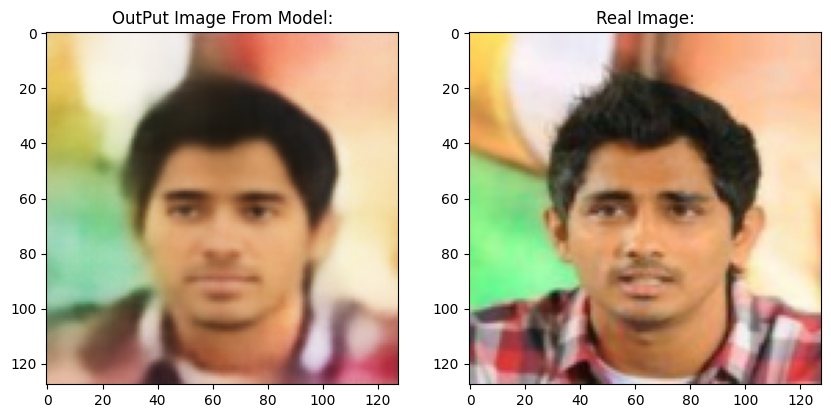

In [ ]:
"""
#
# show the orginal image along with predicted image:
#
"""
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,10))

ax1.set_title("OutPut Image From Model:")
ax1.imshow(ouput_image[0])

ax2.set_title("Real Image:")
ax2.imshow(real_image.permute(1,2,0).contiguous())
plt.show()


In [ ]:
# ------------------------------------------
#
# demo image: 01 (real image)
#
# ------------------------------------------

from torchvision.transforms import  v2

img_input = Image.open("noushad.jpg").convert("RGB")
transform = transforms.Compose([
    transforms.Resize((128, 128)),

    #v2.GaussianBlur(kernel_size=3, sigma=0.5),
    transforms.ToTensor()
])
real_image = transform(img_input)
img_input = real_image.unsqueeze(0)
print(img_input.shape)



torch.Size([1, 3, 128, 128])


torch.Size([1, 3, 128, 128])
ouput shape from model: torch.Size([128, 128, 3])


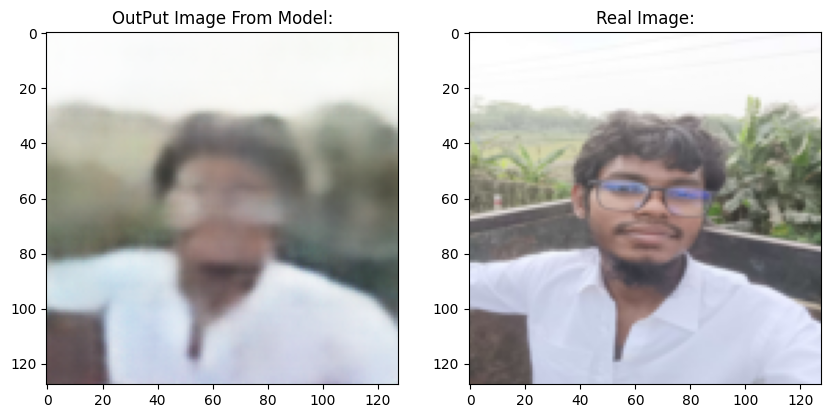

In [ ]:
"""
- Predict the output from our trained model:
"""
ouput_image = []
model.eval()
with torch.no_grad():
  img_input = img_input.to(device)
  recon, mean, std = model(img_input)
  #print(recon)
  print(recon.shape)
  ouput_image.append(recon.cpu().squeeze(0).permute(1, 2, 0))
print(f"ouput shape from model: {ouput_image[0].shape}")

"""
#
# show the orginal image along with predicted image:
#
"""
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,10))

ax1.set_title("OutPut Image From Model:")
ax1.imshow(ouput_image[0])

ax2.set_title("Real Image:")
ax2.imshow(real_image.permute(1,2,0).contiguous())
plt.show()



torch.Size([1, 3, 128, 128])
torch.Size([1, 3, 128, 128])
ouput shape from model: torch.Size([128, 128, 3])


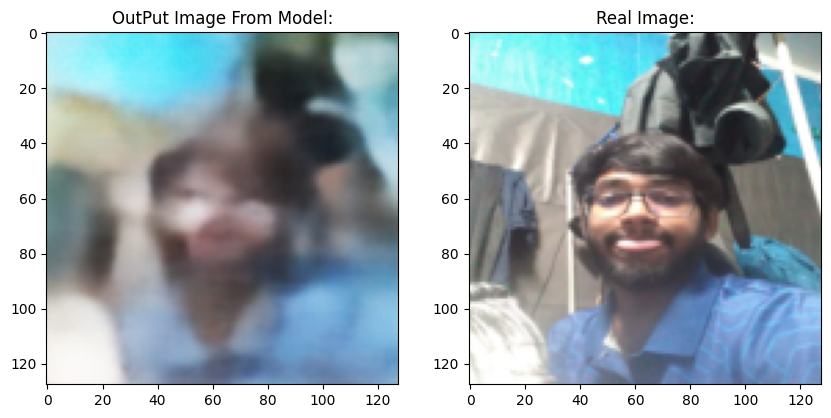

In [ ]:
# ------------------------------------------
#
# demo image: 02 (real_image)
#
# ------------------------------------------

img_input = Image.open("benoy.jpg").convert("RGB")
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])
real_image = transform(img_input)
img_input = real_image.unsqueeze(0)
print(img_input.shape)

ouput_image = []
model.eval()
with torch.no_grad():
  img_input = img_input.to(device)
  recon, mean, std = model(img_input)
  #print(recon)
  print(recon.shape)
  ouput_image.append(recon.cpu().squeeze(0).permute(1, 2, 0))
print(f"ouput shape from model: {ouput_image[0].shape}")

"""
#
# show the orginal image along with predicted image:
#
"""
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,10))

ax1.set_title("OutPut Image From Model:")
ax1.imshow(ouput_image[0])

ax2.set_title("Real Image:")
ax2.imshow(real_image.permute(1,2,0).contiguous())
plt.show()

<br>
<br>

# `# Google Drive Connection:`

<br>
<br>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# `#Unzip Files:`

In [ ]:
!unzip "/content/drive/My Drive/img_align_celeba.zip"

Streaming output truncated to the last 5000 lines.
 extracting: img_align_celeba/197600.jpg  
 extracting: img_align_celeba/197601.jpg  
 extracting: img_align_celeba/197602.jpg  
 extracting: img_align_celeba/197603.jpg  
 extracting: img_align_celeba/197604.jpg  
 extracting: img_align_celeba/197605.jpg  
 extracting: img_align_celeba/197606.jpg  
 extracting: img_align_celeba/197607.jpg  
 extracting: img_align_celeba/197608.jpg  
 extracting: img_align_celeba/197609.jpg  
 extracting: img_align_celeba/197610.jpg  
 extracting: img_align_celeba/197611.jpg  
 extracting: img_align_celeba/197612.jpg  
 extracting: img_align_celeba/197613.jpg  
 extracting: img_align_celeba/197614.jpg  
 extracting: img_align_celeba/197615.jpg  
 extracting: img_align_celeba/197616.jpg  
 extracting: img_align_celeba/197617.jpg  
 extracting: img_align_celeba/197618.jpg  
 extracting: img_align_celeba/197619.jpg  
 extracting: img_align_celeba/197620.jpg  
 extracting: img_align_celeba/197621.jpg  
 ex